# Explainable Hybrid AI Prototype (Ayurvedic Decision Support System) — Implementation Demonstration

7COSC013W.1 Foundations of AI — Coursework 1

This notebook demonstrates the existing modular implementation. It uses stored aggregate evidence, a fitted frozen model bundle, read only SQLite queries and synthetic Phase 9 inputs. It does **not** retrain the model, access the final-test partition, load row level final test predictions, diagnose a condition, infer a medically true Dosha, prescribe treatment or provide exact dosage.

## 1. Portable setup and integrity boundary

The project root is discovered by looking upwards for `pyproject.toml`; no active absolute machine path is embedded. Evidence-reading helpers record every direct notebook read. The production database hash is captured before any demonstration component runs.

In [1]:
from pathlib import Path
import hashlib
import json
import re
import sqlite3
import sys

import joblib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import JSON, Markdown, display

search_starts = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next(path for path in search_starts if (path / "pyproject.toml").is_file())
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

FILES_ACCESSED: list[str] = []

def load_json_evidence(relative_path: str) -> dict:
    path = (PROJECT_ROOT / relative_path).resolve()
    if PROJECT_ROOT.resolve() not in path.parents:
        raise ValueError("Evidence path must remain inside the project.")
    FILES_ACCESSED.append(relative_path)
    return json.loads(path.read_text(encoding="utf-8"))

def load_csv_evidence(relative_path: str) -> pd.DataFrame:
    path = (PROJECT_ROOT / relative_path).resolve()
    if PROJECT_ROOT.resolve() not in path.parents:
        raise ValueError("Evidence path must remain inside the project.")
    FILES_ACCESSED.append(relative_path)
    return pd.read_csv(path)

DATABASE_PATH = PROJECT_ROOT / "data/knowledge_base/ayurvedic_knowledge.db"
DATABASE_HASH_BEFORE = hashlib.sha256(DATABASE_PATH.read_bytes()).hexdigest().upper()
FILES_ACCESSED.append("data/knowledge_base/ayurvedic_knowledge.db (read-only)")

print(f"Project discovered: {PROJECT_ROOT.name}")
print(f"Python: {sys.version.split()[0]}")
print(f"Production database SHA-256 before demonstrations: {DATABASE_HASH_BEFORE}")
print("Frozen boundary: no training, Phase 10 execution, row-level final-test access or persistence")

Project discovered: submission_candidate
Python: 3.12.7
Production database SHA-256 before demonstrations: E52BD930AEE515F32012AC24359E7A94F4B4F726B0A5F86465185B1D2103ADFD
Frozen boundary: no training, Phase 10 execution, row-level final-test access or persistence


## 2. Implemented architecture and module map

The Phase 9 configuration fixes the order as: validate input, resolve the caller selected condition, run the safety gate, invoke the frozen ML model only if permitted, retrieve inside the resolved condition, and compose a provenance-separated result. The table maps each responsibility to the real reusable project module.

In [2]:
hybrid_config = load_json_evidence("config/hybrid_pipeline.v1.json")
module_map = pd.DataFrame([
    ("Input validation", "src/integration/input_schema.py", "Validates the caller-selected condition, symptom text and structured facts."),
    ("Frozen ML adapter", "src/integration/model_adapter.py", "Verifies and invokes the already-fitted Phase 4 bundle with frozen thresholds."),
    ("SQLite knowledge base", "src/knowledge_base/database.py; src/knowledge_base/repository.py", "Provides normalized, provenance-aware storage and read access."),
    ("IF–THEN rule engine", "src/knowledge_base/rule_engine.py; src/knowledge_base/rule_schema.py", "Validates and deterministically evaluates stored rules."),
    ("FTS5/BM25 retrieval", "src/retrieval/profile_retriever.py", "Resolves aliases and ranks condition-scoped text records."),
    ("Safety gate", "src/integration/safety_gate.py", "Runs referral rules before model-personalized retrieval and fails closed."),
    ("Hybrid orchestration", "src/integration/hybrid_pipeline.py", "Calls components in the frozen deterministic order."),
    ("Trace and provenance", "src/integration/result_composer.py", "Keeps model, dataset and reference-checked outputs separate."),
], columns=["Component", "Real project file", "Responsibility"])

for path_group in module_map["Real project file"]:
    for relative_path in path_group.split("; "):
        assert (PROJECT_ROOT / relative_path).is_file(), relative_path

display(pd.DataFrame({
    "Execution step": range(1, len(hybrid_config["component_order"]) + 1),
    "Frozen component order": hybrid_config["component_order"],
}))
display(module_map)

,Execution step,Frozen component order
0,1,validate_input
1,2,resolve_condition
2,3,safety_gate
3,4,frozen_ml_model
4,5,condition_scoped_retrieval
5,6,compose_result


,Component,Real project file,Responsibility
0,Input validation,src/integration/input_schema.py,"Validates the caller-selected condition, sympt..."
1,Frozen ML adapter,src/integration/model_adapter.py,Verifies and invokes the already-fitted Phase ...
2,SQLite knowledge base,src/knowledge_base/database.py; src/knowledge_...,"Provides normalized, provenance-aware storage ..."
3,IF–THEN rule engine,src/knowledge_base/rule_engine.py; src/knowled...,Validates and deterministically evaluates stor...
4,FTS5/BM25 retrieval,src/retrieval/profile_retriever.py,Resolves aliases and ranks condition-scoped te...
5,Safety gate,src/integration/safety_gate.py,Runs referral rules before model-personalized ...
6,Hybrid orchestration,src/integration/hybrid_pipeline.py,Calls components in the frozen deterministic o...
7,Trace and provenance,src/integration/result_composer.py,"Keeps model, dataset and reference-checked out..."


**Interpretation.** Condition resolution is caller-controlled rather than symptom-based diagnosis. The rule-based safety gate precedes the ML adapter, and the composer does not turn rule priority, model probability, BM25 relevance or evidence status into one artificial score.

## 3. Safe aggregate dataset evidence

Only the stored Phase 1 audit and Phase 2 preprocessing report are read. The raw dataset, cleaned rows, split assignments and individual profiles are not opened. All source fields are textual (`object`) fields in the audit; the table below shows their aggregate completeness and uniqueness.

In [3]:
audit = load_json_evidence("outputs/audit/phase1_audit_report.json")
preprocess = load_json_evidence("data/processed/preprocessing_report.json")

shape_and_groups = pd.DataFrame([
    ("Knowledge profiles", audit["schema"]["row_count"]),
    ("Source columns", audit["schema"]["column_count"]),
    ("Raw unique disease names", audit["disease"]["raw_unique_disease_count"]),
    ("Normalized disease groups", audit["disease"]["normalized_disease_group_count"]),
    ("Repeated disease groups", preprocess["duplicates"]["repeated_disease_group_count"]),
    ("Conflicting target groups", audit["disease"]["conflicting_target_group_count"]),
], columns=["Stored aggregate", "Value"])
display(shape_and_groups)

column_evidence = pd.DataFrame(audit["schema"]["columns"]).rename(columns={
    "name": "Source column", "dtype": "Stored dtype",
    "non_null_count": "Initial parser non-null", "unique_non_null_count": "Unique non-null",
})
with pd.option_context("display.max_rows", 40):
    display(column_evidence)

quality_totals = audit["value_quality"]["totals"]
phase2_missing = preprocess["missing_and_placeholders"]
placeholder_counts = phase2_missing["placeholder_counts_by_clean_column"]
missing_summary = pd.DataFrame([
    ("Phase 1 parser missing-like cells", quality_totals["missing"], "Initial CSV parsing treated textual placeholders such as None as missing-like."),
    ("Phase 2 source-preserving true blank/null cells", phase2_missing["true_missing_cells_in_source"], "Source-preserving load distinguished true blanks from textual placeholders."),
    ("Textual placeholders converted only in cleaned columns", sum(placeholder_counts.values()), phase2_missing["policy"]),
    ("Explicit-negative phrases retained as data", quality_totals["explicit_negative"], "Not silently converted into unknown or safe."),
    ("Ambiguous textual values", quality_totals["ambiguous"], "Retained for explicit review."),
], columns=["Missingness or placeholder finding", "Count", "Interpretation"])
display(missing_summary)
display(pd.DataFrame(
    sorted(placeholder_counts.items(), key=lambda item: (-item[1], item[0])),
    columns=["Cleaned field with textual placeholder", "Count"],
))

duplicate_summary = pd.DataFrame([
    ("Exact duplicate extra rows", preprocess["duplicates"]["exact_duplicate_extra_rows"]),
    ("Normalized duplicate extra rows", preprocess["duplicates"]["normalized_duplicate_extra_rows"]),
], columns=["Duplicate check", "Count"])
display(duplicate_summary)

label_presence = pd.DataFrame(
    list(audit["dosha"]["per_label_presence"].items()),
    columns=["Dataset-assigned label", "Positive profiles"],
)
combination_distribution = pd.DataFrame(
    list(audit["dosha"]["canonical_distribution"].items()),
    columns=["Canonical label combination", "Profiles"],
).sort_values("Profiles", ascending=False)
display(label_presence)
display(combination_distribution)

risks = list(dict.fromkeys(audit["limitations"] + preprocess["limitations"]))
display(Markdown("**Stored major data-quality risks**\n\n" + "\n".join(f"- {risk}" for risk in risks)))

,Stored aggregate,Value
0,Knowledge profiles,446
1,Source columns,34
2,Raw unique disease names,367
3,Normalized disease groups,363
4,Repeated disease groups,73
5,Conflicting target groups,48


,Source column,Stored dtype,Initial parser non-null,Unique non-null
0,Disease,object,446,367
1,Hindi Name,object,446,390
2,Marathi Name,object,446,405
3,Symptoms,object,446,429
4,Diagnosis & Tests,object,446,310
5,Symptom Severity,object,446,7
6,Duration of Treatment,object,446,59
7,Medical History,object,445,371
8,Current Medications,object,446,287
9,Risk Factors,object,446,330


,Missingness or placeholder finding,Count,Interpretation
0,Phase 1 parser missing-like cells,400,Initial CSV parsing treated textual placeholde...
1,Phase 2 source-preserving true blank/null cells,0,Source-preserving load distinguished true blan...
2,Textual placeholders converted only in cleaned...,400,Placeholders become pd.NA only in cleaned colu...
3,Explicit-negative phrases retained as data,71,Not silently converted into unknown or safe.
4,Ambiguous textual values,1,Retained for explicit review.


,Cleaned field with textual placeholder,Count
0,allergies_food_env,350
1,herbal_alternative_remedies,15
2,yoga_and_physical_therapy,14
3,ayurvedic_herbs,10
4,prevention,9
5,family_history,1
6,medical_history,1


,Duplicate check,Count
0,Exact duplicate extra rows,0
1,Normalized duplicate extra rows,0


,Dataset-assigned label,Positive profiles
0,Vata,252
1,Pitta,307
2,Kapha,119


,Canonical label combination,Profiles
0,Vata + Pitta,133
1,Pitta,132
2,Vata,62
3,Vata + Kapha,57
4,Pitta + Kapha,42
5,Kapha,20


**Stored major data-quality risks**

- The audit does not establish that rows are independent patient records.
- The provenance and clinical authority of profile content are unverified.
- Feature screens are diagnostics, not automated inclusion decisions.
- No preprocessing, splitting, modelling, or recommendation evaluation was run.
- Rows are knowledge profiles, not verified independent patient cases.
- Dataset provenance, medical accuracy, and labeling process are unverified.
- String-based leakage tests cannot detect every semantic or templated proxy.
- Cleaning does not make dataset-derived Dosha tags clinically valid.

**Interpretation.** The source-preserving Phase 2 load found no genuinely blank/null cells; the 400 missing-like values from the initial parser correspond to textual placeholders recorded by field and converted to `pd.NA` only in cleaned columns. This distinction prevents `None` from being interpreted as “no allergy.” Zero duplicate rows do not imply 446 independent cases: there are only 363 normalized disease groups, 73 repeated groups and 48 groups with conflicting target combinations.

## 4. Preprocessing and leakage controls

Raw values are preserved separately. Cleaned fields normalize Unicode, apostrophes, whitespace, delimiter variants and conservative categorical spellings. Disease normalization is used for grouping, while Dosha order is canonicalized before three binary dataset-label targets are created. The final model uses symptoms only, and its transformers were fitted only on training profiles.

In [4]:
feature_policy = preprocess["model_feature_policy"]
display(pd.DataFrame({
    "Policy": ["Initially allowed for Phase 4 experiments", "Explicitly excluded"],
    "Fields": [
        ", ".join(feature_policy["allowed_initial_features"]),
        ", ".join(feature_policy["excluded_fields"]),
    ],
}))
display(pd.DataFrame([
    ("Symptom delimiter policy", preprocess["symptoms"]["policy"]),
    ("Medical History", feature_policy["medical_history_status"]),
    ("Family History", feature_policy["family_history_status"]),
], columns=["Control", "Stored decision"]))

,Policy,Fields
0,Initially allowed for Phase 4 experiments,"symptoms, symptom_severity, age_group, gender,..."
1,Explicitly excluded,"allergies_food_env, ayurvedic_herbs, complicat..."


,Control,Stored decision
0,Symptom delimiter policy,"Split on comma, semicolon, slash, or vertical ..."
1,Medical History,excluded pending manual leakage review
2,Family History,excluded because disease-name leakage is frequent


**Interpretation.** Disease names, target fields and post-diagnosis knowledge were blocked from the model. Medical and Family History remained excluded. Group-disjoint splitting and train-only fitting reduce leakage, but templated wording and semantic proxies can still weaken generalization.

## 5. Stored validation comparison and fitted frozen model

This section retains the approved validation table and chart, then safely inspects the already-fitted model bundle. It reads stored Phase 4 validation metrics and the approved Phase 10 aggregate metrics JSON only. It does not load `final_test_predictions.csv`, transform final test rows, predict or recalculate a metric.

In [5]:
comparison = load_csv_evidence("outputs/phase4_validation/validation_comparison.csv")
comparison_columns = [name for name in [
    "feature_experiment", "model", "threshold_mode", "macro_f1",
    "micro_f1", "samples_f1", "hamming_loss",
    "exact_match_subset_accuracy", "jaccard_samples",
] if name in comparison.columns]
display(comparison[comparison_columns].round(4))

phase4_manifest = load_json_evidence("outputs/phase4_validation/model_selection_manifest.json")
display(JSON({
    "selected_model": phase4_manifest["selected_model"],
    "features": phase4_manifest["features"],
    "hyperparameters": phase4_manifest["hyperparameters"],
    "thresholds": phase4_manifest["thresholds"],
    "primary_selection_metric": phase4_manifest["primary_selection_metric"],
    "random_seed": phase4_manifest["random_seed"],
    "rationale": phase4_manifest["rationale"],
    "near_tie_limitation": phase4_manifest["limitation"],
}))

,feature_experiment,model,threshold_mode,macro_f1,micro_f1,samples_f1,hamming_loss,exact_match_subset_accuracy,jaccard_samples
0,symptoms_only,dummy_prior,default_0.5,0.5171,0.7143,0.7065,0.3383,0.2836,0.5896
1,symptoms_only,dummy_prior,validation_tuned,0.6644,0.6820,0.6657,0.4826,0.0000,0.5174
2,symptoms_only,logistic_regression_ovr,default_0.5,0.6659,0.7184,0.7179,0.2886,0.3582,0.6269
3,symptoms_only,logistic_regression_ovr,validation_tuned,0.7298,0.7615,0.7567,0.2836,0.3433,0.6567
4,symptoms_only,random_forest_ovr,default_0.5,0.7105,0.7707,0.7786,0.2338,0.5075,0.7065
5,symptoms_only,random_forest_ovr,validation_tuned,0.7272,0.7719,0.7746,0.2587,0.4478,0.6891
6,symptoms_plus_categorical,dummy_prior,default_0.5,0.5171,0.7143,0.7065,0.3383,0.2836,0.5896
7,symptoms_plus_categorical,dummy_prior,validation_tuned,0.6644,0.6820,0.6657,0.4826,0.0000,0.5174
8,symptoms_plus_categorical,logistic_regression_ovr,default_0.5,0.5888,0.6667,0.6443,0.3284,0.4030,0.5796
9,symptoms_plus_categorical,logistic_regression_ovr,validation_tuned,0.6967,0.7381,0.7383,0.3284,0.3134,0.6318


<IPython.core.display.JSON object>

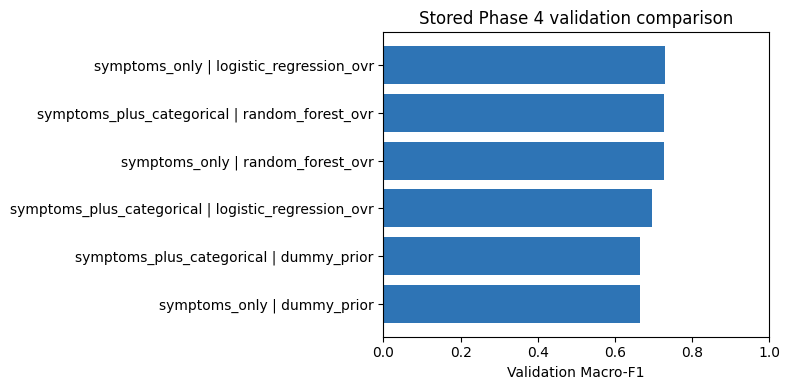

In [6]:
plot_rows = comparison.copy()
if "threshold_mode" in plot_rows.columns:
    plot_rows = plot_rows[
        plot_rows["threshold_mode"].astype(str).str.contains("tuned", case=False, na=False)
    ]
plot_rows = plot_rows.sort_values("macro_f1")
plot_labels = plot_rows["feature_experiment"].astype(str) + " | " + plot_rows["model"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_labels, plot_rows["macro_f1"], color="#2E74B5")
ax.set_xlabel("Validation Macro-F1")
ax.set_title("Stored Phase 4 validation comparison")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

In [7]:
from integration.model_adapter import LABELS
from sklearn.utils.validation import check_is_fitted

bundle_relative_path = "models/phase4_validation/provisional_best_bundle.joblib"
bundle_path = PROJECT_ROOT / bundle_relative_path
FILES_ACCESSED.append(bundle_relative_path)
actual_bundle_hash = hashlib.sha256(bundle_path.read_bytes()).hexdigest().upper()
expected_bundle_hash = phase4_manifest["artifacts"]["saved_model_bundle"]["sha256"]
assert actual_bundle_hash == expected_bundle_hash

frozen_bundle = joblib.load(bundle_path)
frozen_pipeline = frozen_bundle["pipeline"]
preprocessor = frozen_pipeline.named_steps["preprocessor"]
classifier = frozen_pipeline.named_steps["classifier"]
check_is_fitted(preprocessor)
check_is_fitted(classifier)
first_fitted_estimator = classifier.estimators_[0]
already_fitted = hasattr(preprocessor, "transformers_") and len(classifier.estimators_) == 3

frozen_configuration = pd.DataFrame([
    ("Pipeline class", type(frozen_pipeline).__name__),
    ("Multi-label wrapper", type(classifier).__name__),
    ("Fitted base model class", type(first_fitted_estimator).__name__),
    ("C", first_fitted_estimator.C),
    ("class_weight", first_fitted_estimator.class_weight),
    ("random_state", first_fitted_estimator.random_state),
    ("feature columns", ", ".join(frozen_bundle["feature_columns"])),
    ("label order", ", ".join(LABELS)),
    ("thresholds", ", ".join(str(value) for value in frozen_bundle["thresholds"])),
    ("already fitted", already_fitted),
    ("bundle hash verified", actual_bundle_hash == expected_bundle_hash),
], columns=["Frozen property", "Actual stored value"])
display(frozen_configuration)

phase4_metrics = load_json_evidence("outputs/phase4_validation/phase4_metrics.json")
selected_record = next(
    record for record in phase4_metrics["candidate_results"]
    if record["candidate"] == phase4_manifest["implementation_candidate"]
)
validation_metrics = selected_record["metrics_tuned"]
validation_table = pd.DataFrame([
    ("Macro-F1", validation_metrics["macro_f1"]),
    ("Micro-F1", validation_metrics["micro_f1"]),
    ("Samples-F1", validation_metrics["samples_f1"]),
    ("Hamming loss", validation_metrics["hamming_loss"]),
    ("Exact-match accuracy", validation_metrics["exact_match_subset_accuracy"]),
    ("Jaccard", validation_metrics["jaccard_samples"]),
], columns=["Stored validation metric", "Value"])
display(validation_table.round(6))

phase10_metrics = load_json_evidence(
    "outputs/phase10_final_evaluation/final_test_metrics.json"
)
final_aggregate = pd.DataFrame([
    ("Macro-F1", phase10_metrics["primary_metric"]["value"]),
    ("Micro-F1", phase10_metrics["secondary_metrics"]["micro_f1"]),
    ("Weighted-F1", phase10_metrics["secondary_metrics"]["weighted_f1"]),
    ("Samples-F1", phase10_metrics["secondary_metrics"]["samples_f1"]),
    ("Hamming loss", phase10_metrics["secondary_metrics"]["hamming_loss"]),
    ("Exact-match accuracy", phase10_metrics["secondary_metrics"]["exact_match_subset_accuracy"]),
    ("Jaccard", phase10_metrics["secondary_metrics"]["jaccard_samples"]),
], columns=["Stored final-test aggregate metric", "Value"])
display(final_aggregate.round(6))

per_label_rows = []
for label in LABELS:
    values = phase10_metrics["per_label"][label]
    per_label_rows.append({"Label": label, **values})
display(pd.DataFrame(per_label_rows).round(6))

display(pd.DataFrame([
    ("Validation evidence", "outputs/phase4_validation/validation_comparison.csv; phase4_metrics.json"),
    ("Frozen selection evidence", "outputs/phase4_validation/model_selection_manifest.json"),
    ("Final aggregate evidence", "outputs/phase10_final_evaluation/final_test_metrics.json"),
    ("Row-level final predictions", "NOT ACCESSED"),
], columns=["Evidence role", "File used"]))

,Frozen property,Actual stored value
0,Pipeline class,Pipeline
1,Multi-label wrapper,OneVsRestClassifier
2,Fitted base model class,LogisticRegression
3,C,0.5
4,class_weight,balanced
5,random_state,42
6,feature columns,symptoms
7,label order,"Vata, Pitta, Kapha"
8,thresholds,"0.45, 0.45, 0.45"
9,already fitted,True


,Stored validation metric,Value
0,Macro-F1,0.729814
1,Micro-F1,0.761506
2,Samples-F1,0.756716
3,Hamming loss,0.283582
4,Exact-match accuracy,0.343284
5,Jaccard,0.656716


,Stored final-test aggregate metric,Value
0,Macro-F1,0.626241
1,Micro-F1,0.697479
2,Weighted-F1,0.706196
3,Samples-F1,0.692537
4,Hamming loss,0.358209
5,Exact-match accuracy,0.238806
6,Jaccard,0.577114


,Label,precision,recall,f1,support,tn,fp,fn,tp
0,Vata,0.653061,0.864865,0.744186,37,13,17,5,32
1,Pitta,0.745763,0.936170,0.830189,47,5,15,3,44
2,Kapha,0.250000,0.388889,0.304348,18,28,21,11,7


,Evidence role,File used
0,Validation evidence,outputs/phase4_validation/validation_compariso...
1,Frozen selection evidence,outputs/phase4_validation/model_selection_mani...
2,Final aggregate evidence,outputs/phase10_final_evaluation/final_test_me...
3,Row-level final predictions,NOT ACCESSED


**Interpretation.** The stored bundle is an already-fitted symptoms-only `Pipeline` containing a `OneVsRestClassifier` over three fitted Logistic Regression estimators. Its `C=0.5`, balanced class weighting, seed 42, Vata/Pitta/Kapha order and three 0.45 thresholds match the frozen manifest. The displayed validation and final-test values were loaded rather than recalculated. They measure agreement with dataset-assigned labels, not clinical confidence, Ayurvedic correctness or true Dosha identification.

## 6. Read-only SQLite knowledge-base inspection

The connection uses SQLite URI `mode=ro` and `PRAGMA query_only=ON`. The inventory includes logical, audit and FTS5 tables. Selected schemas, named indexes, indexed columns and technical triggers are displayed without executing medical reasoning or exposing dosage content.

In [8]:
connection = sqlite3.connect(f"file:{DATABASE_PATH.as_posix()}?mode=ro", uri=True)
connection.row_factory = sqlite3.Row
connection.execute("PRAGMA foreign_keys = ON")
connection.execute("PRAGMA query_only = ON")

all_table_names = [row["name"] for row in connection.execute(
    "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
)]
table_inventory = []
for table_name in all_table_names:
    quoted = table_name.replace('"', '""')
    row_count = connection.execute(f'SELECT COUNT(*) FROM "{quoted}"').fetchone()[0]
    table_inventory.append({
        "Table": table_name,
        "Rows": row_count,
        "Category": "FTS5 structure" if "_fts" in table_name else "Logical or technical table",
    })
display(pd.DataFrame(table_inventory))

selected_schema_tables = [
    "conditions", "knowledge_claims", "evidence_sources",
    "knowledge_rules", "recommendations", "retrieval_results",
]
schema_rows = []
for table_name in selected_schema_tables:
    for column in connection.execute(f'PRAGMA table_info("{table_name}")'):
        schema_rows.append({
            "Table": table_name,
            "Column": column["name"],
            "Type": column["type"],
            "Not null": bool(column["notnull"]),
            "Primary key position": column["pk"],
        })
display(pd.DataFrame(schema_rows))

,Table,Rows,Category
0,audit_log,65,Logical or technical table
1,claim_evidence,15,Logical or technical table
2,condition_aliases,15,Logical or technical table
3,condition_doshas,9,Logical or technical table
4,condition_symptoms,36,Logical or technical table
5,conditions,5,Logical or technical table
6,contraindications,0,Logical or technical table
7,doshas,3,Logical or technical table
8,evidence_sources,5,Logical or technical table
9,final_recommendation_claims,0,Logical or technical table


,Table,Column,Type,Not null,Primary key position
0,conditions,condition_id,INTEGER,False,1
1,conditions,canonical_name,TEXT,True,0
2,conditions,normalized_name,TEXT,True,0
3,conditions,description,TEXT,True,0
4,conditions,provenance_status,TEXT,True,0
...,...,...,...,...,...
74,retrieval_results,source_profile_id,TEXT,True,0
75,retrieval_results,similarity_score,REAL,True,0
76,retrieval_results,retrieval_method,TEXT,True,0
77,retrieval_results,created_at,TEXT,True,0


In [9]:
index_rows = []
for index_record in connection.execute(
    "SELECT name, tbl_name FROM sqlite_master "
    "WHERE type='index' AND name NOT LIKE 'sqlite_autoindex_%' ORDER BY tbl_name, name"
):
    index_name = index_record["name"]
    quoted_index = index_name.replace('"', '""')
    indexed_columns = [
        row["name"] for row in connection.execute(f'PRAGMA index_info("{quoted_index}")')
    ]
    index_rows.append({
        "Table": index_record["tbl_name"],
        "Index name": index_name,
        "Indexed columns": ", ".join(column for column in indexed_columns if column),
    })
display(pd.DataFrame(index_rows))

def trigger_purpose(name: str) -> str:
    if name.endswith("_fts_ai"):
        return "Synchronize an inserted row into its FTS5 index."
    if name.endswith("_fts_au"):
        return "Synchronize an updated row into its FTS5 index."
    if name.endswith("_fts_ad"):
        return "Remove a deleted row from its FTS5 index."
    if "stale" in name:
        return "Mark dependent knowledge or rule records stale after supporting evidence changes."
    if "audit" in name:
        return "Record an important technical insert or update in the audit log."
    return "Technical database-maintenance trigger."

trigger_names = [row["name"] for row in connection.execute(
    "SELECT name FROM sqlite_master WHERE type='trigger' ORDER BY name"
)]
display(pd.DataFrame(
    [(name, trigger_purpose(name)) for name in trigger_names],
    columns=["Trigger name", "Short technical purpose"],
))

fts_structures = [name for name in all_table_names if "_fts" in name]
display(pd.DataFrame({"FTS5 table or shadow structure": fts_structures}))

,Table,Index name,Indexed columns
0,audit_log,idx_audit_log_entity,"entity_type, entity_id"
1,audit_log,idx_audit_log_timestamp,event_timestamp
2,claim_evidence,idx_claim_evidence_claim,claim_id
3,claim_evidence,idx_claim_evidence_source,source_id
4,condition_aliases,idx_condition_aliases_condition_id,condition_id
5,condition_aliases,idx_condition_aliases_normalized_alias,normalized_alias
6,condition_doshas,idx_condition_doshas_claim,claim_id
7,condition_doshas,idx_condition_doshas_condition,"condition_id, dosha_id"
8,condition_doshas,idx_condition_doshas_dosha,"dosha_id, condition_id"
9,condition_symptoms,idx_condition_symptoms_claim,claim_id


,Trigger name,Short technical purpose
0,trg_conditions_ai_audit,Record an important technical insert or update...
1,trg_conditions_au_audit,Record an important technical insert or update...
2,trg_evidence_sources_ai_audit,Record an important technical insert or update...
3,trg_evidence_sources_au_stale,Mark dependent knowledge or rule records stale...
4,trg_final_recommendations_ai_audit,Record an important technical insert or update...
5,trg_final_recommendations_au_audit,Record an important technical insert or update...
6,trg_knowledge_claims_ai_audit,Record an important technical insert or update...
7,trg_knowledge_claims_au_stale,Mark dependent knowledge or rule records stale...
8,trg_phase7_claim_rules_stale,Mark dependent knowledge or rule records stale...
9,trg_phase7_knowledge_rules_ai_audit,Record an important technical insert or update...


,FTS5 table or shadow structure
0,recommendation_search_fts
1,recommendation_search_fts_config
2,recommendation_search_fts_data
3,recommendation_search_fts_docsize
4,recommendation_search_fts_idx
5,symptom_search_fts
6,symptom_search_fts_config
7,symptom_search_fts_data
8,symptom_search_fts_docsize
9,symptom_search_fts_idx


In [10]:
reference_claims = pd.read_sql_query(
    "SELECT c.canonical_name AS condition, k.claim_id, k.claim_type, "
    "k.claim_summary, k.evidence_status, e.source_id, "
    "e.publisher, e.page_title, ce.source_locator "
    "FROM knowledge_claims AS k "
    "JOIN conditions AS c ON c.condition_id = k.condition_id "
    "JOIN claim_evidence AS ce ON ce.claim_id = k.claim_id "
    "JOIN evidence_sources AS e ON e.source_id = ce.source_id "
    "WHERE k.evidence_status = 'reference_checked' AND k.is_active = 1 "
    "ORDER BY c.canonical_name, k.claim_id LIMIT 5",
    connection,
)
display(reference_claims)

dataset_dosha_provenance = pd.read_sql_query(
    "SELECT c.canonical_name AS condition, cd.condition_dosha_id, "
    "cd.source_profile_id, cd.original_dosha_text, "
    "cd.relationship_status, cd.conflict_note "
    "FROM condition_doshas AS cd "
    "JOIN conditions AS c ON c.condition_id = cd.condition_id "
    "ORDER BY c.canonical_name, cd.source_profile_id, cd.condition_dosha_id",
    connection,
)
display(dataset_dosha_provenance)

,condition,claim_id,claim_type,claim_summary,evidence_status,source_id,publisher,page_title,source_locator
0,Acne,KC-ACNE-REF-SAFE-001,referral_consideration,NHS advises GP assessment for moderate or seve...,reference_checked,SRC-NHS-ACNE,NHS,Acne,When to seek medical advice
1,Acne,KC-ACNE-REF-SELF-001,general_self_care,Avoid picking or squeezing acne spots because ...,reference_checked,SRC-NHS-ACNE,NHS,Acne,Things you can try if you have acne
2,Acne,KC-ACNE-REF-SYM-001,symptom,Acne can involve spots and oily skin; affected...,reference_checked,SRC-NHS-ACNE,NHS,Acne,Overview and Symptoms of acne
3,Common Cold,KC-COLD-REF-SAFE-001,referral_consideration,NHS advises GP assessment when cold symptoms w...,reference_checked,SRC-NHS-COLD,NHS,Common cold,Non-urgent advice: See a GP if
4,Common Cold,KC-COLD-REF-SELF-001,general_self_care,Rest and adequate fluids are general self-care...,reference_checked,SRC-NHS-COLD,NHS,Common cold,How you can treat a cold yourself


,condition,condition_dosha_id,source_profile_id,original_dosha_text,relationship_status,conflict_note
0,Acne,5,kp_0016,Pitta,dataset_derived,None
1,Common Cold,1,kp_0006,"Kapha, Vata",dataset_derived,None
2,Common Cold,2,kp_0006,"Kapha, Vata",dataset_derived,None
3,Gastroesophageal Reflux Disease,6,kp_0114,Pitta,dataset_derived,None
4,Insomnia,3,kp_0010,"Vata, Pitta",dataset_derived,Conflicting profile-level Dosha combinations r...
5,Insomnia,4,kp_0010,"Vata, Pitta",dataset_derived,Conflicting profile-level Dosha combinations r...
6,Insomnia,7,kp_0150,Vata,dataset_derived,Conflicting profile-level Dosha combinations r...
7,Osteoarthritis,8,kp_0226,"Vata, Kapha",dataset_derived,None
8,Osteoarthritis,9,kp_0226,"Vata, Kapha",dataset_derived,None


**Interpretation.** The database stores claims and their sources separately from dataset relationships. The sample claims are specifically reference-checked, while the Dosha associations retain `dataset_derived` provenance and source profile IDs. Insomnia’s conflicting Vata and Vata/Pitta relationships remain visible rather than being resolved. FTS5 triggers only maintain search indexes; audit and staleness triggers contain technical—not diagnostic—logic.

## 7. Standalone IF–THEN rule demonstration

The existing `RuleEngine` evaluates an explicitly selected Acne context and safe synthetic facts. Setting `picks_or_squeezes_spots=True` demonstrates one reference-checked general-information rule firing, while the referral predicate remains false. No notebook-only rule is created.

In [11]:
from knowledge_base.rule_engine import RuleEngine

rule_demo_facts = {
    "acne_severity": "mild",
    "has_nodules": False,
    "has_cysts": False,
    "picks_or_squeezes_spots": True,
}
rule_demo_result = RuleEngine(connection).evaluate("Acne", rule_demo_facts)
display(JSON({"synthetic_condition": "Acne", "synthetic_facts": rule_demo_facts}))

rule_ids = [trace["rule_id"] for trace in rule_demo_result["explanation_trace"]]
placeholders = ",".join("?" for _ in rule_ids)
rule_name_lookup = {
    row["rule_id"]: row["rule_name"]
    for row in connection.execute(
        f"SELECT rule_id, rule_name FROM knowledge_rules WHERE rule_id IN ({placeholders})",
        rule_ids,
    )
}
rule_trace_rows = []
for trace in rule_demo_result["explanation_trace"]:
    rule_trace_rows.append({
        "Rule ID": trace["rule_id"],
        "Rule name": rule_name_lookup.get(trace["rule_id"]),
        "Type": trace["rule_type"],
        "Conditions evaluated": json.dumps(trace["predicate_results"], ensure_ascii=False),
        "Outcome": trace["outcome"],
        "Fired": trace["fired"],
        "Why": f"Predicate result was {trace['predicate_results']['result']}.",
        "Action type": trace["proposed_action"]["type"],
        "Evidence status": trace["evidence_status"],
        "Claim IDs": ", ".join(trace["supporting_claim_ids"]),
        "Source IDs": ", ".join(trace["supporting_source_ids"]),
    })
with pd.option_context("display.max_colwidth", 120):
    display(pd.DataFrame(rule_trace_rows))

action_rows = [{
    "Rule ID": action["rule_id"],
    "Finding type": action["type"],
    "Candidate information finding": action["message"],
    "Provenance": "reference_checked",
} for action in rule_demo_result["candidate_actions"]]
display(pd.DataFrame(action_rows))

<IPython.core.display.JSON object>

,Rule ID,Rule name,Type,Conditions evaluated,Outcome,Fired,Why,Action type,Evidence status,Claim IDs,Source IDs
0,R-ACNE-REFERRAL-001,Acne professional-assessment information,professional_referral,"{""operator"": ""any"", ""result"": ""false"", ""children"": [{""field"": ""acne_severity"", ""operator"": ""in"", ""expected"": [""moder...",not_fired,False,Predicate result was false.,professional_referral,reference_checked,KC-ACNE-REF-SAFE-001,SRC-NHS-ACNE
1,R-ACNE-SELFCARE-001,Acne spot-handling information,general_recommendation,"{""field"": ""picks_or_squeezes_spots"", ""operator"": ""eq"", ""expected"": true, ""actual"": true, ""result"": ""true""}",fired,True,Predicate result was true.,general_recommendation,reference_checked,KC-ACNE-REF-SELF-001,SRC-NHS-ACNE


,Rule ID,Finding type,Candidate information finding,Provenance
0,R-ACNE-SELFCARE-001,general_recommendation,Reference-checked NHS information advises avoi...,reference_checked


**Interpretation.** Both active Acne rules were considered. The referral rule did not fire because severity was mild and no nodules or cysts were supplied. The general-information rule fired because the synthetic fact explicitly matched its checked predicate. This is a traceable candidate information action, not a diagnosis, prescription or guarantee of benefit.

## 8. Standalone condition-scoped FTS5/BM25 retrieval

The caller supplies the alias `GERD`; retrieval resolves it before searching. BM25 and safe term coverage rank only records inside Gastroesophageal Reflux Disease. Lexical relevance is not evidence strength, treatment safety or medical correctness.

In [12]:
from retrieval.profile_retriever import ProfileRetriever
from retrieval.query_schema import load_retrieval_config

retriever = ProfileRetriever(
    connection,
    config=load_retrieval_config(PROJECT_ROOT / "config/retrieval_config.v1.json"),
)
retrieval_result = retriever.retrieve({
    "condition": "GERD",
    "free_text": "heartburn acid reflux",
    "categories": ["profiles", "claims", "symptoms", "recommendations", "sources"],
    "top_k": 3,
})
display(JSON({
    "status": retrieval_result["status"],
    "resolved_condition": retrieval_result["resolved_condition"],
    "matched_alias": retrieval_result["matched_alias"],
    "fts5": retrieval_result["fts5"],
}))

def safe_result_summary(item: dict) -> str:
    content = item["content"]
    if "claim_summary" in content:
        return content["claim_summary"]
    if "symptom_text" in content:
        return content["symptom_text"]
    if "page_title" in content:
        return f"{content.get('publisher', '')}: {content['page_title']}"
    if "profile_claims" in content:
        return " | ".join(claim["claim_summary"] for claim in content["profile_claims"][:3])
    if "category" in content:
        return content["category"]
    return item["result_type"]

retrieval_rows = []
for collection_name, items in retrieval_result["collections"].items():
    for item in items:
        scores = item["component_scores"]
        retrieval_rows.append({
            "Collection": collection_name,
            "Record ID": item["record_id"],
            "Rank": item["rank"],
            "Raw BM25 (smaller is better)": scores["raw_bm25_smaller_is_better"],
            "BM25 normalized": scores["bm25_normalized"],
            "Lexical relevance": scores["lexical_relevance"],
            "Final retrieval score": item["final_retrieval_score"],
            "Matched terms": ", ".join(item["matched_query_terms"]),
            "Safe title or summary": safe_result_summary(item),
            "Evidence status": item["evidence_status"],
            "Source/profile provenance": ", ".join(item["supporting_source_ids"])
                or (item["source_profile_identifier"] or "none"),
        })
with pd.option_context("display.max_colwidth", 100):
    display(pd.DataFrame(retrieval_rows))
print(retrieval_result["lexical_relevance_note"])

<IPython.core.display.JSON object>

,Collection,Record ID,Rank,Raw BM25 (smaller is better),BM25 normalized,Lexical relevance,Final retrieval score,Matched terms,Safe title or summary,Evidence status,Source/profile provenance
0,profiles,kp_0114,1,-4.348024,1.0,0.800000,0.800000,heartburn,Dataset complication text retained from knowledge profile kp_0114. | Dataset-assigned Dosha tags...,dataset_derived,kp_0114
1,claims,KC-GERD-REF-SYM-001,1,NaN,0.0,1.000000,1.000000,"heartburn, acid, reflux",The main acid-reflux symptoms listed by NHS are heartburn and an unpleasant sour taste in the mo...,reference_checked,SRC-NHS-REFLUX
2,claims,KC-GERD-REF-SAFE-001,2,NaN,0.0,0.333333,0.333333,heartburn,"NHS advises GP assessment when self-care and pharmacy measures do not help, heartburn occurs mos...",reference_checked,SRC-NHS-REFLUX
3,claims,KC-GERD-REF-SELF-001,3,NaN,0.0,0.333333,0.333333,heartburn,"NHS lists smaller, more frequent meals and avoiding personally triggering foods or drinks as mea...",reference_checked,SRC-NHS-REFLUX
4,symptoms,SYM-26,1,-4.348024,1.0,0.800000,0.800000,heartburn,heartburn,reference_checked,SRC-NHS-REFLUX
5,symptoms,SYM-9,2,-4.348024,1.0,0.800000,0.800000,heartburn,heartburn,dataset_derived,kp_0114
6,sources,SRC-NHS-REFLUX,1,NaN,0.0,1.000000,1.000000,"heartburn, acid, reflux",NHS: Heartburn and acid reflux,reference_checked,SRC-NHS-REFLUX
7,sources,PROV-kp_0114,2,NaN,0.0,0.333333,0.333333,heartburn,dataset_provenance,dataset_derived,kp_0114


Lexical relevance measures text similarity, not evidence quality or medical correctness.


**Interpretation.** `GERD` resolved deterministically to Gastroesophageal Reflux Disease. Reference-checked claims and sources remain distinguishable from the dataset-derived profile. A high retrieval score indicates closer query/text matching only; evidence status remains a separate categorical field.

## 9. End-to-end deterministic hybrid scenario

The following approved synthetic Acne input is processed in the frozen order. Free text is not converted into safety facts. Output sections are displayed separately so model probabilities, rule outcomes, retrieved records, safety state and provenance retain their different meanings.

In [13]:
from integration.hybrid_pipeline import HybridPipeline

pipeline = HybridPipeline()
normal_request = {
    "condition": "Acne",
    "symptom_text": "facial spots blackheads and oily skin",
    "safety_facts": {
        "acne_severity": "mild",
        "has_nodules": False,
        "has_cysts": False,
        "picks_or_squeezes_spots": False,
    },
    "top_k": 3,
    "request_id": "P12-NOTEBOOK-NORMAL",
}
normal_result = pipeline.run(normal_request)
assert normal_result["result_type"] == "hybrid_decision_support_result"
display(Markdown("### Validated synthetic input"))
display(JSON({
    "submitted_input": normal_request,
    "resolved_condition": normal_result["condition_context"],
    "input_validation_outcome": normal_result["model_prediction"]["input_validation_outcome"],
}))

### Validated synthetic input

<IPython.core.display.JSON object>

In [14]:
display(Markdown("### ML label decisions and uncalibrated probabilities"))
model_rows = [{
    "Label": label,
    "Raw model probability": values["raw_model_probability"],
    "Frozen threshold": values["frozen_threshold"],
    "Threshold decision": values["threshold_decision"],
    "Provenance": normal_result["model_prediction"]["provenance"],
} for label, values in normal_result["model_prediction"]["label_outputs"].items()]
display(pd.DataFrame(model_rows))
print(normal_result["model_prediction"]["not_confidence_statement"])

display(Markdown("### Rule findings and trace"))
hybrid_rule_rows = [{
    "Rule ID": trace["rule_id"],
    "Type": trace["rule_type"],
    "Outcome": trace["outcome"],
    "Facts used": json.dumps(trace["input_facts_used"], ensure_ascii=False),
    "Missing inputs": ", ".join(trace["missing_required_inputs"]) or "none",
    "Finding": trace["proposed_action"]["message"],
    "Evidence": trace["evidence_status"],
    "Claims": ", ".join(trace["supporting_claim_ids"]),
    "Sources": ", ".join(trace["supporting_source_ids"]),
} for trace in normal_result["rule_trace"]]
with pd.option_context("display.max_colwidth", 100):
    display(pd.DataFrame(hybrid_rule_rows))

display(Markdown("### Retrieved reference-checked information"))
reference_rows = [{
    "Record ID": item["record_id"],
    "Rank": item["rank"],
    "Summary": item["content"].get("claim_summary", item["result_type"]),
    "Matched terms": ", ".join(item["matched_query_terms"]),
    "Retrieval score": item["final_retrieval_score"],
    "Evidence": item["evidence_status"],
    "Sources": ", ".join(item["supporting_source_ids"]),
} for item in normal_result["reference_checked_information"]]
display(pd.DataFrame(reference_rows))

display(Markdown("### Dataset-derived profile information"))
profile_rows = [{
    "Profile ID": item["record_id"],
    "Rank": item["rank"],
    "Dataset claim summaries": " | ".join(
        claim["claim_summary"] for claim in item["content"]["profile_claims"]
    ),
    "Dataset-assigned tags": ", ".join(item["dosha_overlap_details"]["dataset_assigned_tags"]),
    "Evidence": item["evidence_status"],
    "Limitation": item["limitations"],
} for item in normal_result["dataset_derived_profiles"]]
with pd.option_context("display.max_colwidth", 110):
    display(pd.DataFrame(profile_rows))

display(Markdown("### Dataset-derived recommendation demonstrations"))
recommendation_rows = [{
    "Record ID": item["record_id"],
    "Category": item["content"]["category"],
    "Dataset text": item["content"]["recommendation_text"],
    "Evidence": item["evidence_status"],
    "Authority note": item["authority_note"],
} for item in normal_result["dataset_derived_recommendations"]]
display(pd.DataFrame(recommendation_rows))

### ML label decisions and uncalibrated probabilities

,Label,Raw model probability,Frozen threshold,Threshold decision,Provenance
0,Vata,0.458714,0.45,True,model_generated
1,Pitta,0.534467,0.45,True,model_generated
2,Kapha,0.405049,0.45,False,model_generated


These are model outputs for dataset-assigned tags, not confidence in a true or clinically validated Dosha.


### Rule findings and trace

,Rule ID,Type,Outcome,Facts used,Missing inputs,Finding,Evidence,Claims,Sources
0,R-ACNE-REFERRAL-001,professional_referral,not_fired,"{""acne_severity"": ""mild"", ""has_nodules"": false, ""has_cysts"": false}",none,"Reference-checked NHS information advises GP assessment for moderate or severe acne, or when nod...",reference_checked,KC-ACNE-REF-SAFE-001,SRC-NHS-ACNE
1,R-ACNE-SELFCARE-001,general_recommendation,not_fired,"{""picks_or_squeezes_spots"": false}",none,Reference-checked NHS information advises avoiding picking or squeezing acne spots because this ...,reference_checked,KC-ACNE-REF-SELF-001,SRC-NHS-ACNE


...

,Record ID,Rank,Summary,Matched terms,Retrieval score,Evidence,Sources
0,KC-ACNE-REF-SYM-001,1,Acne can involve spots and oily skin; affected...,"spots, and, oily, skin",0.666667,reference_checked,SRC-NHS-ACNE
1,KC-ACNE-REF-SELF-001,2,Avoid picking or squeezing acne spots because ...,"spots, and",0.333333,reference_checked,SRC-NHS-ACNE


### Dataset-derived profile information

,Profile ID,Rank,Dataset claim summaries,Dataset-assigned tags,Evidence,Limitation
0,kp_0016,1,Dataset complication text retained from knowledge profile kp_0016. | Dataset-assigned Dosha tags: Pitta re...,Pitta,dataset_derived,Dataset-derived knowledge profile; content and assigned Dosha tags are not medically or clinically validated.


### Dataset-derived recommendation demonstrations

,Record ID,Category,Dataset text,Evidence,Authority note
0,REC-6,Dataset prevention,"Clean skin, avoid triggers",dataset_derived,Dataset demonstration only; not verified Ayurv...
1,REC-5,Dataset diet and lifestyle,Avoid fried foods; include turmeric and green ...,dataset_derived,Dataset demonstration only; not verified Ayurv...


In [15]:
display(Markdown("### Safety gate and final orchestration state"))
display(JSON({
    "safety_gate_decision": normal_result["safety_gate_result"],
    "final_orchestration_state": normal_result["orchestration_state"],
    "retrieval_trace": {
        "status": normal_result["retrieval_trace"]["status"],
        "matched_alias": normal_result["retrieval_trace"]["matched_alias"],
        "fts5": normal_result["retrieval_trace"]["fts5"],
        "adapter_trace": normal_result["retrieval_trace"]["adapter_trace"],
        "score_interpretation": normal_result["retrieval_trace"]["score_interpretation"],
    },
}))

display(Markdown("### Suppressed items"))
display(pd.DataFrame(
    normal_result["suppressed_items"]
    if normal_result["suppressed_items"]
    else [{"status": "none returned for this synthetic non-referral scenario"}]
))

display(Markdown("### Invocation trace"))
display(pd.DataFrame({
    "Step": range(1, len(normal_result["invocation_trace"]) + 1),
    "Invoked component": normal_result["invocation_trace"],
}))

display(Markdown("### Provenance and preserved disagreement"))
display(pd.DataFrame([
    ("Model prediction", "model_generated", 1),
    ("Reference-checked information", "reference_checked", len(normal_result["reference_checked_information"])),
    ("Dataset-derived profiles", "dataset_derived", len(normal_result["dataset_derived_profiles"])),
    ("Dataset-derived recommendation demonstrations", "dataset_derived", len(normal_result["dataset_derived_recommendations"])),
], columns=["Section", "Provenance", "Displayed item count"]))
display(JSON({"agreements_and_disagreements": normal_result["agreements_and_disagreements"]}))

### Safety gate and final orchestration state

<IPython.core.display.JSON object>

### Suppressed items

,status
0,none returned for this synthetic non-referral ...


### Invocation trace

,Step,Invoked component
0,1,validate_input
1,2,resolve_condition
2,3,safety_gate
3,4,frozen_ml_model
4,5,condition_scoped_retrieval
5,6,compose_result


### Provenance and preserved disagreement

,Section,Provenance,Displayed item count
0,Model prediction,model_generated,1
1,Reference-checked information,reference_checked,2
2,Dataset-derived profiles,dataset_derived,1
3,Dataset-derived recommendation demonstrations,dataset_derived,2


<IPython.core.display.JSON object>

**Interpretation.** The gate returned `proceed_with_information`, which means only that the implemented referral predicate was fully evaluated and did not fire—not that the input is medically safe. The model’s threshold decisions are uncalibrated dataset-label outputs. Retrieval stays inside Acne, and its score is lexical relevance. Dataset-derived recommendations remain labelled as unverified demonstrations, while the partial model/profile disagreement remains visible.

## 10. Missing-information clarification scenario

This second approved synthetic input omits every structured Common Cold safety fact. Missing values are not interpreted as false or safe, so the gate must stop before the frozen model and retrieval components.

In [16]:
missing_request = {
    "condition": "Common Cold",
    "symptom_text": "runny nose",
    "safety_facts": {},
    "request_id": "P12-NOTEBOOK-CLARIFICATION",
}
missing_result = pipeline.run(missing_request)
missing_gate = missing_result["safety_gate_result"]
not_invoked = [
    component for component in ["frozen_ml_model", "condition_scoped_retrieval"]
    if component not in missing_result["invocation_trace"]
]
blocked_information = []
if not missing_result["model_prediction"]:
    blocked_information.append("ML label personalization")
if not missing_result["retrieval_trace"]:
    blocked_information.append("ML-personalized condition-scoped retrieval")
if not missing_result["dataset_derived_recommendations"]:
    blocked_information.append("dataset-derived personalized recommendation demonstrations")

display(JSON({
    "validated_synthetic_input": missing_request,
    "orchestration_state": missing_result["orchestration_state"],
    "missing_required_facts": missing_gate["missing_structured_fields"],
    "why_processing_stopped": missing_gate["reason"],
    "invocation_trace": missing_result["invocation_trace"],
    "downstream_components_not_invoked": not_invoked,
    "information_not_generated": blocked_information,
    "explicit_suppressed_items": missing_result["suppressed_items"],
}))

clarification_rule_rows = [{
    "Rule ID": trace["rule_id"],
    "Outcome": trace["outcome"],
    "Missing inputs": ", ".join(trace["missing_required_inputs"]),
    "Evidence": trace["evidence_status"],
} for trace in missing_result["rule_trace"]]
display(pd.DataFrame(clarification_rule_rows))

<IPython.core.display.JSON object>

,Rule ID,Outcome,Missing inputs,Evidence
0,R-COLD-REFERRAL-001,not_evaluable,"chest_pain, cold_not_improving, cold_symptom_d...",reference_checked
1,R-COLD-SELFCARE-001,not_evaluable,general_self_care_requested,reference_checked


**Interpretation.** Five structured facts were missing, so the referral rule was `not_evaluable`. The invocation trace ends after result composition: neither the ML adapter nor retrieval ran. The empty explicit-suppression list does not indicate permission; personalized sections were never generated because the safety gate failed closed.

## 11. Stored testing evidence

These values come from the approved Phase 9 manifest. They are implementation and synthetic-scenario checks, not clinical accuracy. The notebook does not run Phase 10.

In [17]:
phase9_manifest = load_json_evidence(
    "outputs/phase9_hybrid_integration/phase9_manifest.json"
)
scenario_evidence = phase9_manifest["scenario_evaluation"]
test_evidence = phase9_manifest["test_results"]
evidence_source = "outputs/phase9_hybrid_integration/phase9_manifest.json"

stored_test_table = pd.DataFrame([
    ("Phase 1–9 regression tests", f"{test_evidence['passed']}/{test_evidence['total_regression_tests']} passed", evidence_source),
    ("Phase 9 synthetic scenarios", f"{scenario_evidence['passed_scenarios']}/{scenario_evidence['scenario_count']} passed", evidence_source),
    ("Safety-state correctness", scenario_evidence["safety_state_correctness"], evidence_source),
    ("Trace completeness", scenario_evidence["trace_completeness"], evidence_source),
    ("Provenance correctness", scenario_evidence["provenance_label_correctness"], evidence_source),
    ("Deterministic repeatability", scenario_evidence["deterministic_repeatability_rate"], evidence_source),
    ("Prohibited positive-output findings", len(phase9_manifest["prohibited_output_findings"]), evidence_source),
    ("Exact-dosage findings", len(phase9_manifest["exact_dosage_findings"]), evidence_source),
], columns=["Stored verification result", "Value", "Evidence source"])
display(stored_test_table)

,Stored verification result,Value,Evidence source
0,Phase 1–9 regression tests,139/139 passed,outputs/phase9_hybrid_integration/phase9_manif...
1,Phase 9 synthetic scenarios,23/23 passed,outputs/phase9_hybrid_integration/phase9_manif...
2,Safety-state correctness,1.0,outputs/phase9_hybrid_integration/phase9_manif...
3,Trace completeness,1.0,outputs/phase9_hybrid_integration/phase9_manif...
4,Provenance correctness,1.0,outputs/phase9_hybrid_integration/phase9_manif...
5,Deterministic repeatability,1.0,outputs/phase9_hybrid_integration/phase9_manif...
6,Prohibited positive-output findings,0,outputs/phase9_hybrid_integration/phase9_manif...
7,Exact-dosage findings,0,outputs/phase9_hybrid_integration/phase9_manif...
